In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import math, os, time, random
from datetime import timedelta
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import SVG, display

from sklearn.metrics import *
from sklearn.model_selection import train_test_split

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

In [3]:
ROOT_DIR = "/kaggle/input/data-skin"
IMG_SIZE = 224
BATCH_SIZE = 6
NUM_WORKERS = 2
RANDOM_STATE = 42
EPOCHS = 8

In [4]:
import torch
print(torch.cuda.get_device_name(0))


Tesla T4


In [5]:
train_dir = "/kaggle/input/datasets/sourabhbettad/dataset-skin/train"
test_dir = "/kaggle/input/datasets/sourabhbettad/dataset-skin/test"

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

CLASSES = train_dataset.classes
num_classes = len(CLASSES)

# Split train → train + val
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

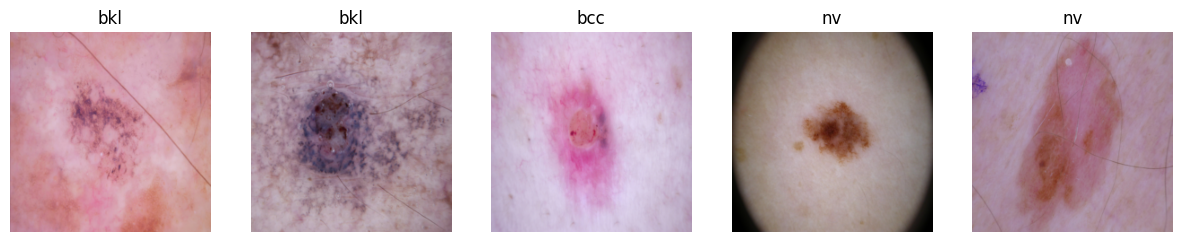

In [6]:
def show_random_images(loader):
    images, labels = next(iter(loader))
    fig, axs = plt.subplots(1, 5, figsize=(15,5))

    for i in range(5):
        axs[i].imshow(images[i].permute(1,2,0))
        axs[i].set_title(CLASSES[labels[i]])
        axs[i].axis("off")

    plt.show()

show_random_images(train_loader)

In [7]:
model = models.mobilenet_v2(weights="DEFAULT")
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [8]:
def custom_metrics(y_pred, y_true, loss):
    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred_classes.cpu().numpy()

    return {
        "loss": loss,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='weighted', zero_division=0),
        "recall": recall_score(y_true, y_pred, average='weighted', zero_division=0),
        "f1_score": f1_score(y_true, y_pred, average='weighted', zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_hist = {"loss":[], "accuracy":[]}
val_hist = {"loss":[], "accuracy":[]}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    all_preds, all_labels = [], []

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        all_preds.append(out)
        all_labels.append(y)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    train_metrics = custom_metrics(all_preds, all_labels, train_loss/len(train_loader))
    print("Train:", train_metrics)

    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    # VALIDATION
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            all_preds.append(out)
            all_labels.append(y)

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    val_metrics = custom_metrics(all_preds, all_labels, val_loss/len(val_loader))
    print("Val:", val_metrics)

    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

100%|██████████| 1069/1069 [02:14<00:00,  7.95it/s]


Train: {'loss': 0.8213731285160228, 'accuracy': 0.7161803713527851, 'precision': 0.672286877410454, 'recall': 0.7161803713527851, 'f1_score': 0.6655747519393982, 'mcc': np.float64(0.36602007858761637)}
Val: {'loss': 0.5879619808019653, 'accuracy': 0.7941359950093575, 'precision': 0.7754700691794082, 'recall': 0.7941359950093575, 'f1_score': 0.7612738561181875, 'mcc': np.float64(0.5618376023232988)}


100%|██████████| 1069/1069 [01:31<00:00, 11.74it/s]


Train: {'loss': 0.576727064369966, 'accuracy': 0.7982524574816664, 'precision': 0.7868154544919015, 'recall': 0.7982524574816664, 'f1_score': 0.7834968162944292, 'mcc': np.float64(0.5939311974448019)}
Val: {'loss': 0.5496659038758683, 'accuracy': 0.8028696194635059, 'precision': 0.7965688057637133, 'recall': 0.8028696194635059, 'f1_score': 0.7736308843025766, 'mcc': np.float64(0.5759078444080419)}


100%|██████████| 1069/1069 [01:25<00:00, 12.46it/s]


...

Train: {'loss': 0.20949704533049068, 'accuracy': 0.931814635668591, 'precision': 0.930990531301577, 'recall': 0.931814635668591, 'f1_score': 0.9311923452285157, 'mcc': np.float64(0.8691193369677469)}
Val: {'loss': 0.6676972711031692, 'accuracy': 0.8184653774173425, 'precision': 0.8061233322288572, 'recall': 0.8184653774173425, 'f1_score': 0.8032172599900759, 'mcc': np.float64(0.6187152193876456)}


100%|██████████| 1069/1069 [01:25<00:00, 12.46it/s]


Train: {'loss': 0.1586660664577396, 'accuracy': 0.947261663286004, 'precision': 0.9468088347094441, 'recall': 0.947261663286004, 'f1_score': 0.9469618692515667, 'mcc': np.float64(0.8990060482663628)}
Val: {'loss': 0.5927768808419455, 'accuracy': 0.827199001871491, 'precision': 0.8256918755702692, 'recall': 0.827199001871491, 'f1_score': 0.8230360396526566, 'mcc': np.float64(0.6529299882238241)}


100%|██████████| 1069/1069 [01:26<00:00, 12.33it/s]


Train: {'loss': 0.11954375798411064, 'accuracy': 0.9630207520674052, 'precision': 0.9628730874908265, 'recall': 0.9630207520674052, 'f1_score': 0.9629311017237159, 'mcc': np.float64(0.9295136460468558)}
Val: {'loss': 0.6440761788761128, 'accuracy': 0.8390517779164067, 'precision': 0.8301477533890943, 'recall': 0.8390517779164067, 'f1_score': 0.8287568450211256, 'mcc': np.float64(0.6667848997557003)}


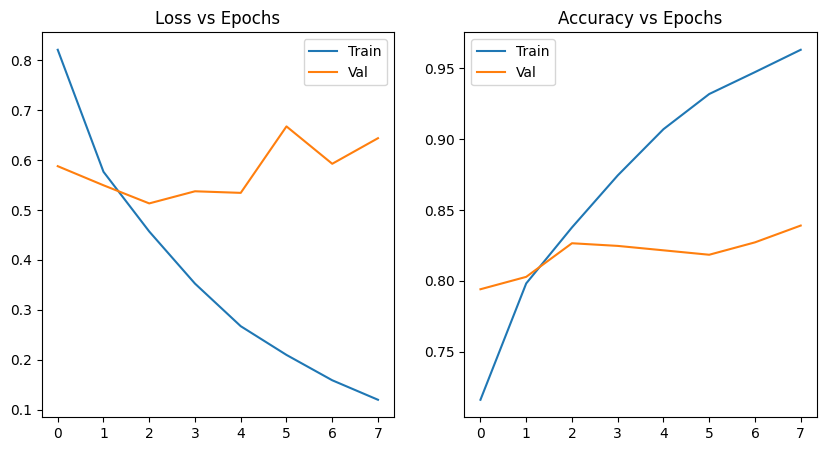

In [10]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(train_hist["loss"], label="Train")
plt.plot(val_hist["loss"], label="Val")
plt.title("Loss vs Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_hist["accuracy"], label="Train")
plt.plot(val_hist["accuracy"], label="Val")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()

In [11]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x,y in test_loader:
        x,y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

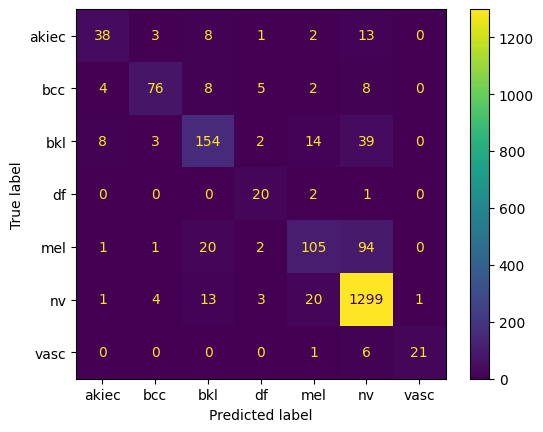

In [12]:
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())
disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot()
plt.show()

In [13]:
print(classification_report(all_labels.cpu(), pred_classes.cpu(), target_names=CLASSES))

              precision    recall  f1-score   support

       akiec       0.73      0.58      0.65        65
         bcc       0.87      0.74      0.80       103
         bkl       0.76      0.70      0.73       220
          df       0.61      0.87      0.71        23
         mel       0.72      0.47      0.57       223
          nv       0.89      0.97      0.93      1341
        vasc       0.95      0.75      0.84        28

    accuracy                           0.86      2003
   macro avg       0.79      0.73      0.75      2003
weighted avg       0.85      0.86      0.85      2003

